# WISE-Only AGN Variability Manifold + Zeltyn et al. (2024) Projection

This notebook:
1. Rebuilds the WISE-only manifold from **Sample A** (Hemmati et al. 2026, arXiv:2601.08037)
2. Trains a UMAP embedding using GP-interpolated W1 light curves with DTW distance
3. Loads the **Zeltyn et al. (2024)** CL-AGN sample (arXiv:2401.01933, SDSS-V first-year)
4. Projects the Zeltyn targets onto the trained manifold using `mapper.transform()`
5. Visualises whether the new CL-AGNs land near the known turn-on/turn-off region

**Reference configuration from the paper:**
- GP regression (`unify_lc_gp`), RBF kernel `length_scale=200`, `xres=160`
- Single band: **W1** (clearest manifold per Figure 4–7 of the paper)
- Normalise by σ-clipped max of W1
- UMAP: `n_neighbors=50`, `min_dist=0.9`, `metric=dtw_distance`

## 0. Setup

In [1]:
import sys, os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import astropy.units as u
import umap
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astroquery.vizier import Vizier
from collections import Counter
from matplotlib.colors import LinearSegmentedColormap

NOTEBOOK_DIR = os.path.abspath('')
sys.path.insert(0, os.path.join(NOTEBOOK_DIR, 'code_src'))

from data_structures import MultiIndexDFObject
from wise_functions import wise_get_lightcurves
from sample_selection import clean_sample
from AGNzoo_functions import (
    unify_lc, unify_lc_gp, stat_bands, combine_bands,
    normalize_clipmax_objects, shuffle_datalabel, dtw_distance,
    stretch_small_values_arctan, translate_bitwise_sum_to_labels, update_bitsums,
)

plt.style.use('bmh')
RANDOM_STATE = 20
DATA_DIR = os.path.join(NOTEBOOK_DIR, 'data')
os.makedirs(DATA_DIR, exist_ok=True)
print('Ready. DATA_DIR =', DATA_DIR)

Ready. DATA_DIR = /Users/shemmati/Desktop/CLAGN/data


## 1. Download & Load Sample A data

In [2]:
PARQUET = os.path.join(DATA_DIR, 'df_lc_020724.parquet.gzip')

if not os.path.exists(PARQUET):
    print('Downloading from Google Drive …')
    import subprocess
    subprocess.run(['gdown', '1gb2vWn0V2unstElGTTrHIIWIftHbXJvz', '-O', PARQUET], check=True)
    print('Done.')
else:
    print('File already exists, skipping download.')

# Load exactly as in ML_AGNzoo.md
df_lc = pd.read_parquet(PARQUET)
df_lc = df_lc[df_lc.index.get_level_values('label') != '64']   # remove SPIDER-only (too large)
df_lc = update_bitsums(df_lc)                                   # clean bitwise sums after removing 64

print('Bands in dataset:', df_lc.index.get_level_values('band').unique().tolist())
print('Total objects:   ', df_lc.index.get_level_values('objectid').nunique())

File already exists, skipping download.
Bands in dataset: ['FERMIGTRIG', 'SAXGRBMGRB', 'zg', 'zr', 'zi', 'W1', 'W2', 'panstarrs r', 'panstarrs i', 'panstarrs z', 'panstarrs g', 'panstarrs y', 'K2', 'TESS', 'k2', 'G', 'BP', 'RP', 'IceCube']
Total objects:    2098


## 2. WISE-only preprocessing (Section 5 of ML_AGNzoo)

In [101]:
# Following ML_AGNzoo.md Section 5 — GP interpolation on W1+W2, xres=160
bands_inlc = ['W1']  # W1 only (best CLAGN separation per Hemmati+2026)

objectsw, dobjectsw, flabelsw, keepsw = unify_lc_gp(
    df_lc, bands_inlc, xres=160, numplots=0, low_limit_size=5
)
print(f'Objects after GP cut: {len(objectsw)}')

fvarw, maxarrayw, meanarrayw = stat_bands(objectsw, dobjectsw, bands_inlc, sigmacl=5)
dat_notnormalw = combine_bands(objectsw, bands_inlc)
datw = normalize_clipmax_objects(dat_notnormalw, maxarrayw, band=0)   # normalise by W1

# Drop NaN rows (objects where clipped max = 0)
valid = ~np.isnan(datw).any(axis=1)
if (~valid).sum():
    print(f'Dropping {(~valid).sum()} objects with NaN features')
datw      = datw[valid]
flabelsw  = [l for l, v in zip(flabelsw, valid) if v]
fvarw     = fvarw[:, valid]
maxarrayw = maxarrayw[:, valid]
meanarrayw = meanarrayw[:, valid]

dataw, fzrw, pw = shuffle_datalabel(datw, flabelsw)
fvar_arrw = fvarw[:, pw]

# Build labc using translate_bitwise_sum_to_labels (same as ML_AGNzoo.md)
labcw = {}
for index, f in enumerate(fzrw):
    for label in translate_bitwise_sum_to_labels(int(f)):
        labcw.setdefault(label, []).append(index)

print('Classes:')
for k, v in sorted(labcw.items(), key=lambda x: -len(x[1])):
    print(f'  {k:20s}: {len(v)}')

0it [00:00, ?it/s]

/opt/anaconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels

Objects after GP cut: 1965
Dropping 5 objects with NaN features
Classes:
  SDSS_QSO            : 965
  WISE_Variable       : 418
  SPIDER_BL           : 154
  SPIDER_AGN          : 137
  SPIDER_QSOBL        : 125
  Turn-off            : 92
  Turn-on             : 76
  Optical_Variable    : 74
  Galex_Variable      : 45
  SPIDER_AGNBL        : 29
  TDE                 : 27


/Users/shemmati/Desktop/CLAGN/code_src/AGNzoo_functions.py:340: RuntimeWarning: divide by zero encountered in divide
  d2[i] = (d / maxarr[band, i])
/Users/shemmati/Desktop/CLAGN/code_src/AGNzoo_functions.py:340: RuntimeWarning: invalid value encountered in divide
  d2[i] = (d / maxarr[band, i])


## 3. Train UMAP on WISE manifold

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1857: UserWarning: custom distance metric does not return gradient; inverse_transform will be unavailable. To enable using inverse_transform method, define a distance function that returns a tuple of (distance [float], gradient [np.array])
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Axes: >

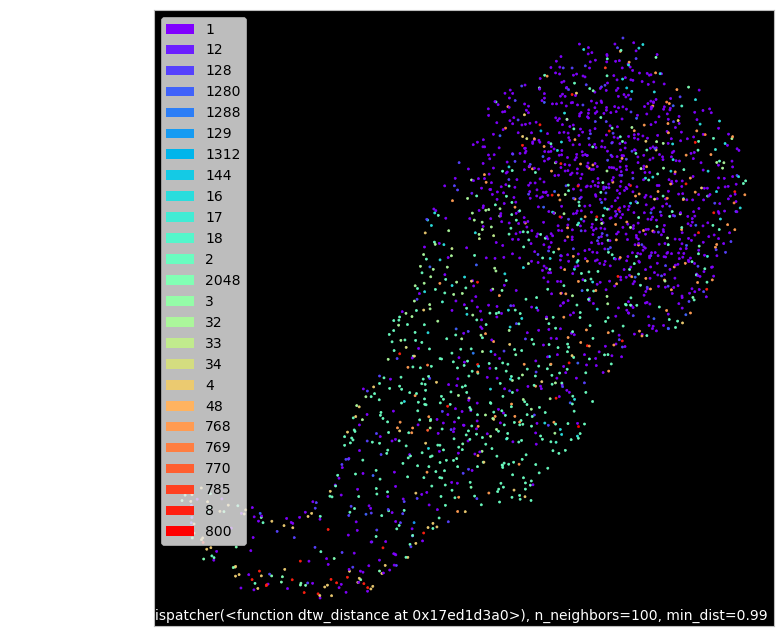

In [129]:
mapp = umap.UMAP(n_neighbors=100, min_dist=0.99,metric=dtw_distance, random_state=3).fit(dataw)
import umap.plot
umap.plot.points(mapp, labels=fzrw, theme='fire')


---
## 5. Build Zeltyn et al. (2024) Sample

Zeltyn et al. (2024, arXiv:2401.01933) present 113 spectroscopically confirmed
CL-AGNs from SDSS-V BHM first-year data.  We try to retrieve the table from
VizieR automatically; if unavailable, a CSV fallback is provided.

In [103]:
def sdss_jname_to_skycoord(jname: str) -> SkyCoord | None:
    """
    Parse an SDSS J-name (e.g. 'SDSS J002806.86-052332.8' or 'J002806.86-052332.8') to SkyCoord.
    """
    # Strip optional 'SDSS ' prefix and the mandatory 'J'
    j = re.sub(r'^(SDSS\s*)?J', '', jname.strip())
    m = re.match(r'(\d{2})(\d{2})(\d{2}\.\d+)([+-])(\d{2})(\d{2})(\d{2}\.\d+)$', j)
    if m is None:
        warnings.warn(f'Could not parse J-name: {jname}')
        return None
    ra_str  = f"{m.group(1)}:{m.group(2)}:{m.group(3)}"
    dec_str = f"{m.group(4)}{m.group(5)}:{m.group(6)}:{m.group(7)}"
    return SkyCoord(ra_str, dec_str, unit=(u.hourangle, u.deg))


def build_zeltyn_sample_table(zeltyn_df: pd.DataFrame) -> Table:
    """
    Convert a DataFrame with columns ['Name', 'Class', 'z'] (and optionally 'RA'/'Dec')
    into an astropy sample_table compatible with wise_get_lightcurves().

    'Class' should be 'CL-AGN' or 'EVQ' (we keep only CL-AGNs by default).
    """
    # Keep confirmed CL-AGNs at z<1 (to match Sample A redshift range)
    cl = zeltyn_df[zeltyn_df['Class'].str.startswith('CL-AGN') & (zeltyn_df['z'] < 1.0)].copy()
    print(f'Zeltyn CL-AGNs at z<1: {len(cl)}')

    coords_z, labels_z = [], []
    for _, row in cl.iterrows():
        # Prefer explicit RA/Dec columns if present
        if 'RA' in row and 'Dec' in row and pd.notna(row['RA']):
            c = SkyCoord(ra=row['RA'] * u.deg, dec=row['Dec'] * u.deg)
        else:
            c = sdss_jname_to_skycoord(row['Name'])
        if c is not None:
            coords_z.append(c)
            labels_z.append('Zeltyn24')

    tbl = clean_sample(coords_z, labels_z, consolidate_nearby_objects=False)
    print(f'Zeltyn CL-AGN sample size: {len(tbl)}')
    return tbl

In [104]:
# Try VizieR for Zeltyn+2024 catalog
zeltyn_df = None
try:
    Vizier.ROW_LIMIT = -1
    catalog_list = Vizier.find_catalogs('2024ApJS..270...27Z')
    if catalog_list:
        cats = Vizier.get_catalogs(list(catalog_list.keys()))
        t5 = cats[0].to_pandas()
        t5 = t5.rename(columns={'SDSS': 'Name', 'Cl': 'Class', 'zsp': 'z'})
        zeltyn_df = t5
        print(f'Downloaded {len(zeltyn_df)} rows from VizieR.')
    else:
        print('VizieR catalog not found – using CSV fallback.')
except Exception as e:
    print(f'VizieR failed ({e}) – using CSV fallback.')


VizieR failed (sequence item 0: expected str instance, NoneType found) – using CSV fallback.


In [105]:
# ── CSV fallback ──────────────────────────────────────────────────────────────
# If VizieR is unavailable, create a CSV file at the path below with columns:
#   Name        – SDSS J-name  (e.g.  SDSS J002806.86-052332.8)
#   Class       – 'CL-AGN' or 'EVQ'
#   z           – spectroscopic redshift
# Optionally add columns RA and Dec (decimal degrees) to skip J-name parsing.

ZELTYN_CSV = os.path.join(DATA_DIR, 'zeltyn2024_table5.csv')

if zeltyn_df is None:
    if os.path.exists(ZELTYN_CSV):
        zeltyn_df = pd.read_csv(ZELTYN_CSV)
        print(f'Loaded {len(zeltyn_df)} rows from {ZELTYN_CSV}')
    else:
        raise FileNotFoundError(
            f'Neither VizieR nor the CSV fallback ({ZELTYN_CSV}) is available.\n'
            'Please download Table 5 from https://arxiv.org/abs/2401.01933 '
            'and save it as a CSV with columns: Name, Class, z.'
        )

# Inspect
print(zeltyn_df.head())
print('Class counts:', zeltyn_df['Class'].value_counts().to_dict())

Loaded 204 rows from /Users/shemmati/Desktop/CLAGN/data/zeltyn2024_table5.csv
                  Name   Class         z
0  J000719.90+253128.6     EVQ  0.559321
1  J000750.51+005815.2  CL-AGN  0.345113
2  J001103.49+010032.6  CL-AGN  0.485892
3  J001133.95-000001.1     EVQ  0.447070
4  J001333.96+014506.8  CL-AGN  0.881555
Class counts: {'CL-AGN': 113, 'EVQ': 88, 'CL-AGN RM': 3}


In [106]:
sample_table_Z = build_zeltyn_sample_table(zeltyn_df)

Zeltyn CL-AGNs at z<1: 111
Object sample size: 111
Zeltyn CL-AGN sample size: 111


---
## 6. Fetch WISE Light Curves for Zeltyn Targets

In [107]:
ZELTYN_PARQUET = os.path.join(DATA_DIR, 'df_lc_zeltyn_wise.parquet.gzip')

if os.path.exists(ZELTYN_PARQUET):
    print('Loading cached Zeltyn light curves …')
    df_lc_Z = MultiIndexDFObject(data=pd.read_parquet(ZELTYN_PARQUET))
else:
    print('Fetching WISE light curves for Zeltyn targets …')
    df_lc_Z = wise_get_lightcurves(
        sample_table_Z,
        radius=1.0,
        bandlist=['WISE_W1', 'WISE_W2'],
    )
    df_lc_Z.data.to_parquet(ZELTYN_PARQUET, compression='gzip')
    print(f'Saved to {ZELTYN_PARQUET}')

# Rename bands (same as Section 2.1)
df_lc_Z.data.index = df_lc_Z.data.index.set_levels(
    df_lc_Z.data.index.levels[df_lc_Z.data.index.names.index('band')].str.replace('WISE_', '', regex=False),
    level='band'
)

n_with_data = df_lc_Z.data.index.get_level_values('objectid').nunique()
print(f'Zeltyn objects with WISE data: {n_with_data} / {len(sample_table_Z)}')

Loading cached Zeltyn light curves …
Zeltyn objects with WISE data: 111 / 111


---
## 7. Preprocess Zeltyn Light Curves

**Identical** pipeline to Section 3 so the feature vectors are comparable.

In [108]:
# Identical pipeline to Sample A — W1+W2, GP, same normalisation band
objects_Z, dobjects_Z, flabels_Z, keeps_Z = unify_lc_gp(
    df_lc_Z.data, bands_inlc, xres=160, numplots=0, low_limit_size=5
)
print(f'Zeltyn objects surviving GP cut: {len(objects_Z)}')

fvar_Z, maxarray_Z, meanarray_Z = stat_bands(objects_Z, dobjects_Z, bands_inlc, sigmacl=5)
dat_notnormal_Z = combine_bands(objects_Z, bands_inlc)
dat_Z = normalize_clipmax_objects(dat_notnormal_Z, maxarray_Z, band=0)

print(f'Zeltyn feature matrix: {dat_Z.shape}')

0it [00:00, ?it/s]

/opt/anaconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Zeltyn objects surviving GP cut: 111
Zeltyn feature matrix: (111, 160)


/Users/shemmati/Desktop/CLAGN/code_src/AGNzoo_functions.py:291: RuntimeWarning: invalid value encountered in sqrt
  fvar = (np.sqrt(varf - deltaf)) / meanf


---
## 8. Project Zeltyn Targets onto the Trained Manifold

`mapper.transform()` performs **out-of-sample** embedding — no retraining.

In [109]:
embedding_Z = mapp.transform(dat_Z)
print(f'Zeltyn projected: {embedding_Z.shape}')

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Zeltyn projected: (111, 2)


## EVQ — Extreme Variability Quasars from Zeltyn et al. (2024)

In [110]:
# Build EVQ sample (same CSV, Class == "EVQ", z < 1)
def build_evq_sample_table(zeltyn_df):
    evq = zeltyn_df[zeltyn_df['Class'] == 'EVQ'].copy()
    evq_z1 = evq[evq['z'] < 1.0]
    print(f'EVQs at z<1: {len(evq_z1)} (of {len(evq)} total EVQs)')
    coords_e, labels_e = [], []
    for _, row in evq_z1.iterrows():
        if 'RA' in row and 'Dec' in row and pd.notna(row['RA']):
            c = SkyCoord(ra=row['RA'] * u.deg, dec=row['Dec'] * u.deg)
        else:
            c = sdss_jname_to_skycoord(row['Name'])
        if c is not None:
            coords_e.append(c)
            labels_e.append('EVQ')
    tbl = clean_sample(coords_e, labels_e, consolidate_nearby_objects=False)
    print(f'EVQ sample table size: {len(tbl)}')
    return tbl

sample_table_E = build_evq_sample_table(zeltyn_df)


EVQs at z<1: 70 (of 88 total EVQs)
Object sample size: 70
EVQ sample table size: 70


In [111]:
EVQ_PARQUET = os.path.join(DATA_DIR, 'df_lc_evq_wise.parquet.gzip')

if os.path.exists(EVQ_PARQUET):
    print('Loading cached EVQ light curves …')
    df_lc_E = MultiIndexDFObject(data=pd.read_parquet(EVQ_PARQUET))
else:
    print('Fetching WISE light curves for EVQ targets …')
    df_lc_E = wise_get_lightcurves(sample_table_E, radius=1.0, bandlist=['WISE_W1'])
    df_lc_E.data.to_parquet(EVQ_PARQUET, compression='gzip')
    print(f'Saved to {EVQ_PARQUET}')

# Rename band
df_lc_E.data.index = df_lc_E.data.index.set_levels(
    df_lc_E.data.index.levels[df_lc_E.data.index.names.index('band')].str.replace('WISE_', '', regex=False),
    level='band')
print(f'EVQ objects with WISE data: {df_lc_E.data.index.get_level_values("objectid").nunique()}')


Fetching WISE light curves for EVQ targets …


  0%|          | 0/95 [00:00<?, ?it/s]

Saved to /Users/shemmati/Desktop/CLAGN/data/df_lc_evq_wise.parquet.gzip
EVQ objects with WISE data: 69


In [112]:
# GP interpolation + normalisation — identical pipeline to CL-AGNs
objects_E, dobjects_E, flabels_E, keeps_E = unify_lc_gp(
    df_lc_E.data, bands_inlc, xres=160, numplots=0, low_limit_size=5
)
print(f'EVQ objects surviving GP cut: {len(objects_E)}')

fvar_E, maxarray_E, _ = stat_bands(objects_E, dobjects_E, bands_inlc, sigmacl=5)
dat_E_raw = normalize_clipmax_objects(combine_bands(objects_E, bands_inlc), maxarray_E, band=0)

# Drop NaN rows (objects where sigma-clipped max == 0)
valid_E = ~np.isnan(dat_E_raw).any(axis=1)
dat_E = dat_E_raw[valid_E]
flabels_E = [l for l, v in zip(flabels_E, valid_E) if v]
print(f'EVQ feature matrix: {dat_E.shape}  (dropped {(~valid_E).sum()} NaN objects)')


0it [00:00, ?it/s]

/opt/anaconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


EVQ objects surviving GP cut: 68
EVQ feature matrix: (68, 160)  (dropped 0 NaN objects)


/Users/shemmati/Desktop/CLAGN/code_src/AGNzoo_functions.py:291: RuntimeWarning: invalid value encountered in sqrt
  fvar = (np.sqrt(varf - deltaf)) / meanf


In [113]:
embedding_E = mapp.transform(dat_E)
print(f'EVQ projected: {embedding_E.shape}')


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


EVQ projected: (68, 2)


---
## 9. Final Plot – Zeltyn CL-AGNs on the Sample A Manifold

/var/folders/3t/27bzm_5577qbf5908lwjw0l00000gp/T/ipykernel_46678/3848462754.py:9: RuntimeWarning: invalid value encountered in divide
  prob = hist_per_cluster / hist
/var/folders/3t/27bzm_5577qbf5908lwjw0l00000gp/T/ipykernel_46678/3848462754.py:20: RuntimeWarning: divide by zero encountered in divide
  prob_zeltyn = hist_zeltyn / hist
/var/folders/3t/27bzm_5577qbf5908lwjw0l00000gp/T/ipykernel_46678/3848462754.py:20: RuntimeWarning: invalid value encountered in divide
  prob_zeltyn = hist_zeltyn / hist
/var/folders/3t/27bzm_5577qbf5908lwjw0l00000gp/T/ipykernel_46678/3848462754.py:29: RuntimeWarning: divide by zero encountered in divide
  prob_zeltyn = hist_zeltyn / hist
/var/folders/3t/27bzm_5577qbf5908lwjw0l00000gp/T/ipykernel_46678/3848462754.py:29: RuntimeWarning: invalid value encountered in divide
  prob_zeltyn = hist_zeltyn / hist


(np.float64(-0.39125028252601624),
 np.float64(18.00017738342285),
 np.float64(-6.942739486694336),
 np.float64(9.036482810974121))

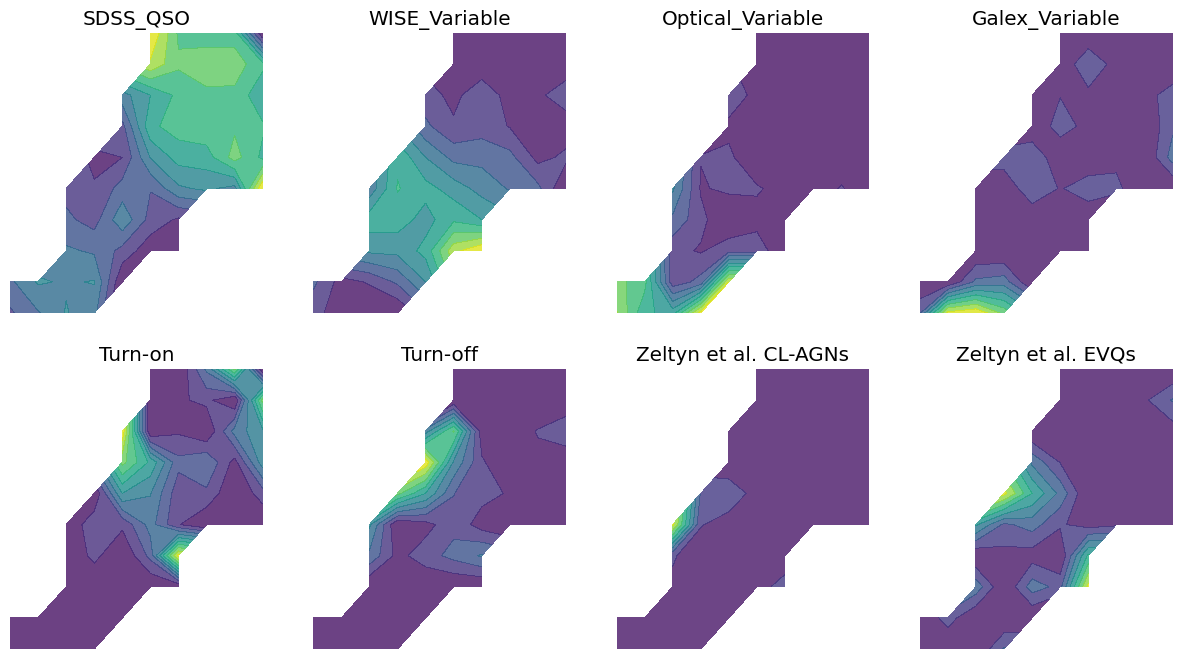

In [128]:

hist, x_edges, y_edges = np.histogram2d(mapp.embedding_[:, 0], mapp.embedding_[:, 1], bins=10)
plt.figure(figsize=(15,8))
i=1
laborder = ['SDSS_QSO','WISE_Variable','Optical_Variable','Galex_Variable','Turn-on','Turn-off']
for label in laborder:
    if label in labcw:
        indices = labcw[label]
        hist_per_cluster, _, _ = np.histogram2d(mapp.embedding_[indices,0], mapp.embedding_[indices,1], bins=(x_edges, y_edges))
        prob = hist_per_cluster / hist
        plt.subplot(2,4,i)
        plt.title(label)
        plt.contourf(x_edges[:-1], y_edges[:-1], prob.T, levels=10, alpha=0.8,cmap='viridis')
        #plt.colorbar()
        plt.axis('off')
        i+=1

ax2 = plt.subplot(2,4,7)
ax2.set_title('Zeltyn et al. CL-AGNs')
hist_zeltyn, _, _ = np.histogram2d(embedding_Z[:, 0],embedding_Z[:, 1],bins=(x_edges, y_edges))
prob_zeltyn = hist_zeltyn / hist
cf = ax2.contourf(x_edges[:-1],y_edges[:-1],prob_zeltyn.T,levels=10,alpha=0.8,cmap='viridis')

#plt.colorbar(cf, ax=ax2)
ax2.axis('off')

ax3 = plt.subplot(2,4,8)
ax3.set_title('Zeltyn et al. EVQs')
hist_zeltyn, _, _ = np.histogram2d(embedding_E[:, 0],embedding_E[:, 1],bins=(x_edges, y_edges))
prob_zeltyn = hist_zeltyn / hist
cf = ax3.contourf(x_edges[:-1],y_edges[:-1],prob_zeltyn.T,levels=10,alpha=0.8,cmap='viridis')

#plt.colorbar(cf, ax=ax3)
ax3.axis('off')

In [125]:
"""
P200 Target Selection from the WISE W1 Variability Manifold
============================================================

Run this AFTER the main notebook (wise_manifold_zeltyn.ipynb) so that
the following variables are already in memory:

  mapp          – trained UMAP object
  emb           – mapp.embedding_ (Sample A, shape Nx2)
  embedding_Z   – Zeltyn CL-AGN projected coordinates (111x2)
  embedding_E   – Zeltyn EVQ projected coordinates (68x2)
  fzrw          – Sample A labels (list of strings)
  labcw         – dict mapping label -> list of indices in emb
  flabels_Z     – Zeltyn CL-AGN labels
  flabels_E     – EVQ labels
  df_lc         – Sample A light curve DataFrame (has objectid, label, etc.)
  hist, x_edges, y_edges  – from your 8-panel plot

Paste this into a new cell at the bottom of your notebook.
"""

# =================================================================
# 1. DEFINE THE "CLAGN REGION" OF THE MANIFOLD
# =================================================================
# We define it as the bins where Zeltyn CL-AGNs are enriched
# relative to the overall population.

import numpy as np
import pandas as pd

emb = mapp.embedding_

# Recompute histograms (same bins as your 8-panel plot)
NBINS = 10
hist_all, x_edges, y_edges = np.histogram2d(
    emb[:, 0], emb[:, 1], bins=NBINS
)

# Zeltyn CL-AGN density
hist_zeltyn, _, _ = np.histogram2d(
    embedding_Z[:, 0], embedding_Z[:, 1], bins=(x_edges, y_edges)
)

# Also compute Turn-off density for comparison
turn_off_idx = labcw.get('Turn-off', [])
hist_turnoff, _, _ = np.histogram2d(
    emb[turn_off_idx, 0], emb[turn_off_idx, 1], bins=(x_edges, y_edges)
)

# Define CLAGN region based on enrichment: bins where the Zeltyn CL-AGN
# fraction significantly exceeds the overall rate.
# Adjust ENRICHMENT_FACTOR to control how selective the region is.
ENRICHMENT_FACTOR = 3  # try 3x, 5x, 10x — higher = tighter region

with np.errstate(invalid='ignore'):
    zeltyn_fraction = np.where(hist_all > 0, hist_zeltyn / hist_all, 0)

overall_zeltyn_rate = len(embedding_Z) / len(emb)
clagn_region_mask = zeltyn_fraction > (ENRICHMENT_FACTOR * overall_zeltyn_rate)

print(f"Overall Zeltyn rate: {overall_zeltyn_rate:.4f}")
print(f"Enrichment threshold ({ENRICHMENT_FACTOR}x): {ENRICHMENT_FACTOR * overall_zeltyn_rate:.4f}")

print(f"CLAGN region: {clagn_region_mask.sum()} bins out of {NBINS**2}")
print(f"Zeltyn CL-AGNs in those bins: {hist_zeltyn[clagn_region_mask].sum():.0f}")
print(f"Turn-off CLAGNs in those bins: {hist_turnoff[clagn_region_mask].sum():.0f}")


# =================================================================
# 2. WHICH SAMPLE A OBJECTS SIT IN THE CLAGN REGION?
# =================================================================

def get_bin_indices(x, y, x_edges, y_edges):
    """Return (ix, iy) bin indices for a point."""
    ix = np.searchsorted(x_edges[1:], x)
    iy = np.searchsorted(y_edges[1:], y)
    ix = np.clip(ix, 0, len(x_edges) - 2)
    iy = np.clip(iy, 0, len(y_edges) - 2)
    return ix, iy

# Check each Sample A object
in_clagn_region = []
for i in range(len(emb)):
    ix, iy = get_bin_indices(emb[i, 0], emb[i, 1], x_edges, y_edges)
    in_clagn_region.append(clagn_region_mask[ix, iy])
in_clagn_region = np.array(in_clagn_region)

labels_array = np.array(fzrw)

print(f"\n{'='*60}")
print("SAMPLE A OBJECTS IN THE CLAGN REGION")
print(f"{'='*60}")
print(f"Total Sample A objects: {len(emb)}")
print(f"Objects in CLAGN region: {in_clagn_region.sum()}")
print(f"\nBreakdown by label:")
for lab in sorted(set(fzrw)):
    mask_lab = labels_array == lab
    n_total = mask_lab.sum()
    n_in_region = (mask_lab & in_clagn_region).sum()
    frac = n_in_region / n_total * 100 if n_total > 0 else 0
    print(f"  {lab:25s}: {n_in_region:4d} / {n_total:4d} ({frac:5.1f}%)")

# Non-CLAGN objects in the CLAGN region = P200 CANDIDATES
is_known_clagn = np.isin(labels_array, ['Turn-on', 'Turn-off'])
candidates_mask = in_clagn_region & ~is_known_clagn
n_candidates = candidates_mask.sum()
print(f"\n>>> NON-CLAGN objects in CLAGN region (Tier 2 candidates): {n_candidates}")


# =================================================================
# 3. WHICH EVQs SIT IN THE CLAGN REGION?
# =================================================================

evq_in_clagn = []
for i in range(len(embedding_E)):
    ix, iy = get_bin_indices(embedding_E[i, 0], embedding_E[i, 1], x_edges, y_edges)
    evq_in_clagn.append(clagn_region_mask[ix, iy])
evq_in_clagn = np.array(evq_in_clagn)

print(f"\n{'='*60}")
print("EVQs IN THE CLAGN REGION (Tier 1 candidates)")
print(f"{'='*60}")
print(f"Total EVQs projected: {len(embedding_E)}")
print(f"EVQs in CLAGN region: {evq_in_clagn.sum()}")
print(f"EVQs outside CLAGN region: {(~evq_in_clagn).sum()}")


# =================================================================
# 4. WHICH ZELTYN CLAGNs ARE IN THE CLAGN REGION? (sanity check)
# =================================================================

zeltyn_in_clagn = []
for i in range(len(embedding_Z)):
    ix, iy = get_bin_indices(embedding_Z[i, 0], embedding_Z[i, 1], x_edges, y_edges)
    zeltyn_in_clagn.append(clagn_region_mask[ix, iy])
zeltyn_in_clagn = np.array(zeltyn_in_clagn)

print(f"\n{'='*60}")
print("SANITY CHECK: Zeltyn CL-AGNs in CLAGN region")
print(f"{'='*60}")
print(f"Zeltyn CL-AGNs in region: {zeltyn_in_clagn.sum()} / {len(embedding_Z)}")
print(f"  ({100*zeltyn_in_clagn.sum()/len(embedding_Z):.0f}%)")


# =================================================================
# 5. BUILD TARGET LIST WITH COORDINATES
# =================================================================
# Extract objectids and coordinates for the Tier 2 candidates

print(f"\n{'='*60}")
print("BUILDING TARGET LIST")
print(f"{'='*60}")

# Get the objectids from Sample A
# The objectids should be accessible from df_lc
all_objectids = df_lc.index.get_level_values('objectid').unique()

# We need to map from the embedding index back to objectids
# The embedding was built from dataw, which was built from objects
# that survived the GP cut. The keeps variable tracks which objects
# survived. If you have 'keeps' in memory, use it. Otherwise,
# we use the label array fzrw which should be in the same order.

# Try to get coordinates from the original data
try:
    # Get unique objectids in order (matching embedding order)
    # This depends on how your pipeline orders things
    # The label array fzrw should match the embedding row order
    
    candidate_indices = np.where(candidates_mask)[0]
    
    print(f"\nTier 2 candidates (non-CLAGN in CLAGN region):")
    print(f"  Count: {len(candidate_indices)}")
    print(f"  Labels: {Counter(labels_array[candidate_indices])}")
    
    # If you have redshift info:
    # candidate_redshifts = redshifts_array[candidate_indices]
    # z_mask = candidate_redshifts < 0.5
    # print(f"  At z < 0.5: {z_mask.sum()}")
    
except Exception as e:
    print(f"  Could not extract coordinates: {e}")
    print(f"  You'll need to cross-match the embedding indices back to")
    print(f"  your source catalog to get RA, Dec, redshift, and magnitude.")


# =================================================================
# 6. CONTROL SAMPLE: opposite side of the manifold
# =================================================================

# Define "anti-CLAGN" region: bins with NO Zeltyn or Turn-off objects
# AND with reasonable Sample A density
anti_clagn_mask = (hist_zeltyn == 0) & (hist_turnoff == 0) & (hist_all > 5)

in_anti_clagn = []
for i in range(len(emb)):
    ix, iy = get_bin_indices(emb[i, 0], emb[i, 1], x_edges, y_edges)
    in_anti_clagn.append(anti_clagn_mask[ix, iy])
in_anti_clagn = np.array(in_anti_clagn)

# Non-CLAGN objects in the anti-CLAGN region = CONTROL TARGETS
control_mask = in_anti_clagn & ~is_known_clagn
print(f"\n{'='*60}")
print("CONTROL SAMPLE (Tier 4: anti-CLAGN region)")
print(f"{'='*60}")
print(f"Objects in anti-CLAGN region: {in_anti_clagn.sum()}")
print(f"Non-CLAGN objects there (control pool): {control_mask.sum()}")
print(f"Labels: {Counter(labels_array[control_mask])}")


# =================================================================
# 7. SUMMARY FOR PROPOSAL
# =================================================================

print(f"\n{'='*60}")
print("PROPOSAL TARGET SUMMARY")
print(f"{'='*60}")
print(f"Tier 1 - EVQs in CLAGN region:              {evq_in_clagn.sum()}")
print(f"Tier 2 - Non-CLAGN Sample A in CLAGN region: {candidates_mask.sum()}")
print(f"Tier 3 - Confirmed Zeltyn CLAGNs to revisit: ~5-10 (choose brightest)")
print(f"Tier 4 - Control (anti-CLAGN region):        {control_mask.sum()} (pick ~10-15)")
print(f"")
print(f"Total Tier 1+2 candidates:                   {evq_in_clagn.sum() + candidates_mask.sum()}")
print(f"")
print(f"For 2 nights (~40-80 spectra), select from these pools")
print(f"prioritizing z < 0.5, r < 20, and those with archival SDSS spectra.")

Overall Zeltyn rate: 0.0566
Enrichment threshold (3x): 0.1699
CLAGN region: 8 bins out of 100
Zeltyn CL-AGNs in those bins: 41
Turn-off CLAGNs in those bins: 14

SAMPLE A OBJECTS IN THE CLAGN REGION
Total Sample A objects: 1960
Objects in CLAGN region: 121

Breakdown by label:
  1                        :   19 /  950 (  2.0%)
  12                       :    0 /    1 (  0.0%)
  128                      :    8 /  135 (  5.9%)
  1280                     :    2 /   27 (  7.4%)
  1288                     :    1 /    1 (100.0%)
  129                      :    0 /    1 (  0.0%)
  1312                     :    0 /    1 (  0.0%)
  144                      :    0 /    1 (  0.0%)
  16                       :    3 /   67 (  4.5%)
  17                       :    0 /    3 (  0.0%)
  18                       :    0 /    3 (  0.0%)
  2                        :   56 /  411 ( 13.6%)
  2048                     :    1 /   27 (  3.7%)
  3                        :    0 /    1 (  0.0%)
  32                  

/var/folders/3t/27bzm_5577qbf5908lwjw0l00000gp/T/ipykernel_46678/2876272520.py:56: RuntimeWarning: divide by zero encountered in divide
  zeltyn_fraction = np.where(hist_all > 0, hist_zeltyn / hist_all, 0)


/var/folders/3t/27bzm_5577qbf5908lwjw0l00000gp/T/ipykernel_46678/93546037.py:19: RuntimeWarning: divide by zero encountered in divide
  return np.where(hist_all > 0, h / hist_all, np.nan)


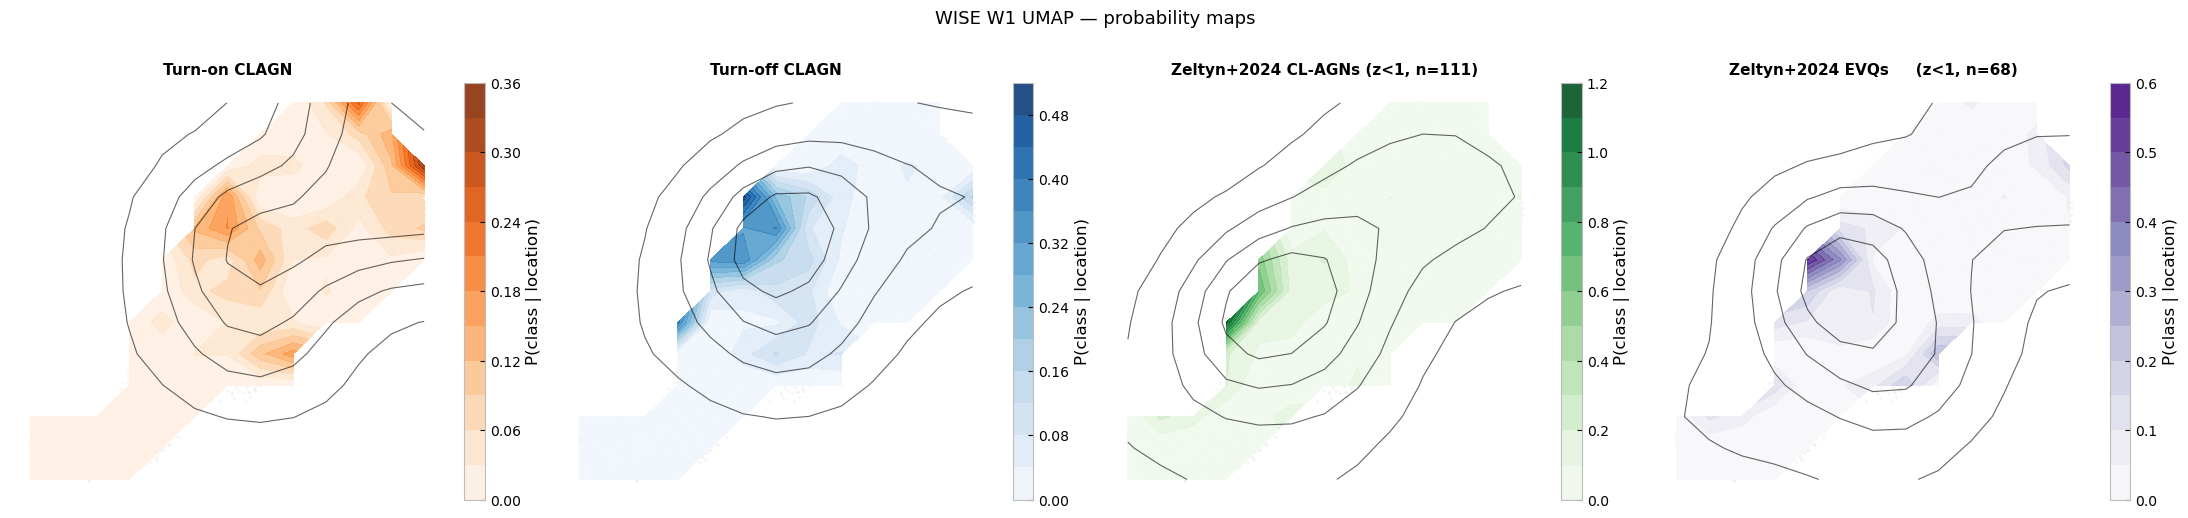

Saved to /Users/shemmati/Desktop/CLAGN/data/probability_maps_4panel.pdf


In [115]:
from scipy.ndimage import gaussian_filter

emb   = mapp.embedding_
NBINS = 13

bw_x = (emb[:,0].max() - emb[:,0].min()) / NBINS / 2
bw_y = (emb[:,1].max() - emb[:,1].min()) / NBINS / 2
hist_all, x_edges, y_edges = np.histogram2d(
    emb[:,0], emb[:,1], bins=NBINS,
    range=[[emb[:,0].min()-bw_x, emb[:,0].max()+bw_x],
           [emb[:,1].min()-bw_y, emb[:,1].max()+bw_y]])
xc = 0.5 * (x_edges[:-1] + x_edges[1:])
yc = 0.5 * (y_edges[:-1] + y_edges[1:])
XX, YY = np.meshgrid(xc, yc)

def prob_map(pts):
    h, _, _ = np.histogram2d(pts[:, 0], pts[:, 1], bins=(x_edges, y_edges))
    with np.errstate(invalid='ignore'):
        return np.where(hist_all > 0, h / hist_all, np.nan)

def smooth_density(pts, sigma=1.5, threshold=0.05):
    """Gaussian-smoothed normalised density for contours."""
    h, _, _ = np.histogram2d(pts[:, 0], pts[:, 1], bins=(x_edges, y_edges))
    h_s = gaussian_filter(h.astype(float), sigma=sigma)
    h_n = h_s / h_s.max() if h_s.max() > 0 else h_s
    h_n[h_n < threshold] = 0
    return h_n

turn_on_pts  = emb[labcw.get('Turn-on',  [])]
turn_off_pts = emb[labcw.get('Turn-off', [])]

# Panels: Turn-on | Turn-off | Zeltyn CL-AGNs | EVQs
panels = [
    (turn_on_pts,  'Turn-on CLAGN',               'Oranges'),
    (turn_off_pts, 'Turn-off CLAGN',               'Blues'),
    (embedding_Z,  f'Zeltyn+2024 CL-AGNs (z<1, n={len(embedding_Z)})', 'Greens'),
    (embedding_E,  f'Zeltyn+2024 EVQs     (z<1, n={len(embedding_E)})', 'Purples'),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)

for ax, (pts, title, cmap) in zip(axes, panels):
    # Grey scatter of full UMAP
    ax.scatter(emb[:, 0], emb[:, 1], s=3, c='lightgrey', alpha=0.15, zorder=0)

    if len(pts) >= 3:
        pm = prob_map(pts)
        # filled probability map
        cf = ax.contourf(XX, YY, pm.T, levels=12, cmap=cmap, alpha=0.88, zorder=1)
        plt.colorbar(cf, ax=ax, fraction=0.046, pad=0.04, label='P(class | location)')

        # smooth contour outline
        sd = smooth_density(pts, sigma=1.5, threshold=0.05)
        lvls = np.linspace(0.1, sd.max(), 5) if sd.max() > 0.1 else None
        if lvls is not None:
            ax.contour(XX, YY, sd.T, levels=lvls, colors='black', linewidths=0.8, zorder=2, alpha=0.6)
    else:
        ax.text(0.5, 0.5, 'Not enough\ndata', ha='center', va='center',
                transform=ax.transAxes, fontsize=11, color='grey')

    ax.set_title(title, size=11, fontweight='bold')
    ax.axis('off')

plt.suptitle('WISE W1 UMAP — probability maps', size=13, y=1.01)
plt.tight_layout()
out = os.path.join(DATA_DIR, 'probability_maps_4panel.pdf')
plt.savefig(out, bbox_inches='tight', dpi=150)
plt.show()
print('Saved to', out)


## 10. CLAGN Enrichment Map (Proposal Figure)

Overall CLAGN fraction in Sample A:    8.6%
Median CLAGN fraction at Zeltyn locs:  6.9%
Enrichment factor:                     0.8x


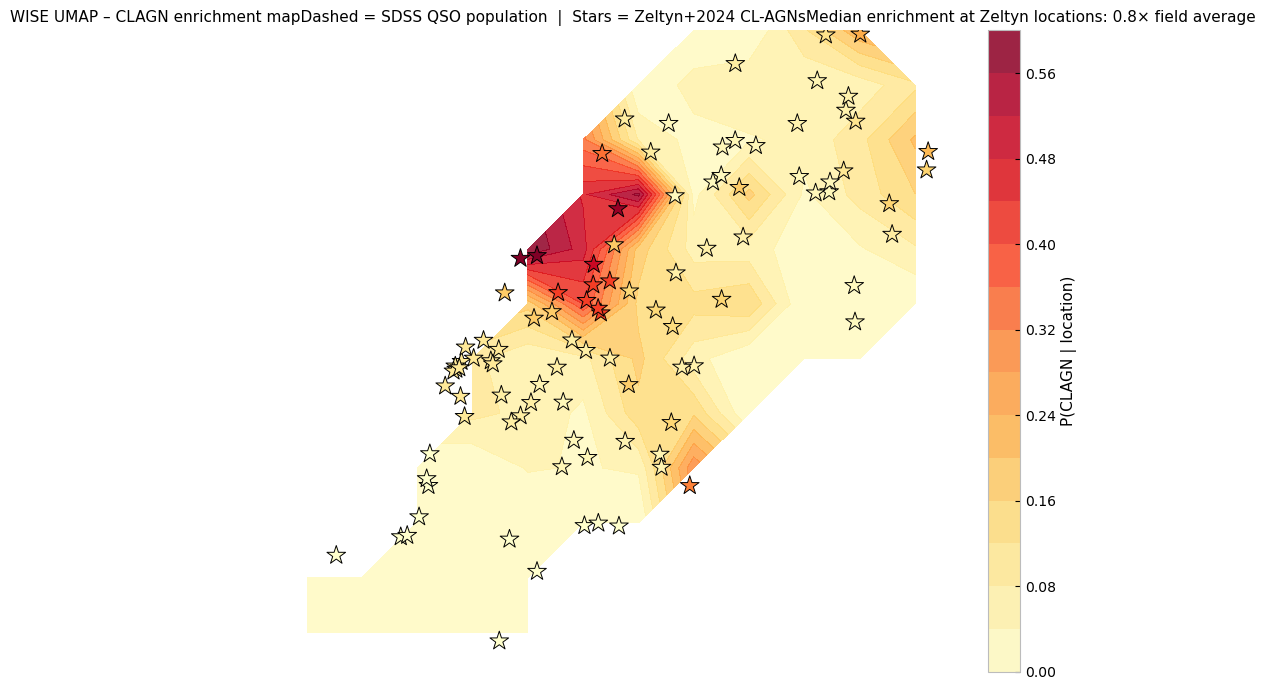

Saved to /Users/shemmati/Desktop/CLAGN/data/enrichment_zeltyn.pdf


In [116]:
from scipy.stats import gaussian_kde
from matplotlib.colors import Normalize

emb = mapp.embedding_
NBINS = 12

# ── CLAGN enrichment: P(CLAGN | location) ────────────────────────────────────
clagn_idx  = labcw.get('Turn-on', []) + labcw.get('Turn-off', [])
sdss_idx   = labcw.get('SDSS_QSO', [])

hist_all,  xe, ye = np.histogram2d(emb[:, 0], emb[:, 1], bins=NBINS)
hist_clagn, _,  _ = np.histogram2d(emb[clagn_idx, 0], emb[clagn_idx, 1], bins=(xe, ye))

with np.errstate(invalid='ignore'):
    enrichment_map = np.where(hist_all > 0, hist_clagn / hist_all, np.nan)

xc = 0.5 * (xe[:-1] + xe[1:])
yc = 0.5 * (ye[:-1] + ye[1:])
XX, YY = np.meshgrid(xc, yc)

# ── Per-Zeltyn-target local enrichment ───────────────────────────────────────
def local_enrichment(point, xe, ye, enrichment_map):
    xi = np.searchsorted(xe[1:], point[0])
    yi = np.searchsorted(ye[1:], point[1])
    xi = np.clip(xi, 0, enrichment_map.shape[0]-1)
    yi = np.clip(yi, 0, enrichment_map.shape[1]-1)
    return enrichment_map[xi, yi]

zeltyn_enrichment = np.array([local_enrichment(p, xe, ye, enrichment_map) for p in embedding_Z])
overall_clagn_fraction = len(clagn_idx) / len(emb)
median_enrichment_factor = np.nanmedian(zeltyn_enrichment) / overall_clagn_fraction

print(f'Overall CLAGN fraction in Sample A:    {100*overall_clagn_fraction:.1f}%')
print(f'Median CLAGN fraction at Zeltyn locs:  {100*np.nanmedian(zeltyn_enrichment):.1f}%')
print(f'Enrichment factor:                     {median_enrichment_factor:.1f}x')

# ── SDSS QSO density contour (background population) ─────────────────────────
kde_sdss = gaussian_kde(emb[sdss_idx].T, bw_method=0.3)
positions = np.vstack([XX.ravel(), YY.ravel()])
sdss_density = kde_sdss(positions).reshape(XX.shape)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

# Enrichment map background
cf = ax.contourf(XX, YY, enrichment_map.T, levels=15, cmap='YlOrRd', alpha=0.85, zorder=1)
cbar = plt.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('P(CLAGN | location)', size=11)

# Zeltyn targets colored by their local enrichment value
sc = ax.scatter(
    embedding_Z[:, 0], embedding_Z[:, 1],
    c=zeltyn_enrichment, cmap='YlOrRd', norm=Normalize(vmin=0, vmax=enrichment_map[~np.isnan(enrichment_map)].max()),
    s=200, marker='*', edgecolors='black', linewidths=0.7, zorder=5,
)

ax.set_title(
    f'WISE UMAP – CLAGN enrichment map'
    f'Dashed = SDSS QSO population  |  Stars = Zeltyn+2024 CL-AGNs'
    f'Median enrichment at Zeltyn locations: {median_enrichment_factor:.1f}× field average',
    size=11,
)
ax.axis('off')
plt.tight_layout()
out = os.path.join(DATA_DIR, 'enrichment_zeltyn.pdf')
plt.savefig(out, bbox_inches='tight', dpi=150)
plt.show()
print('Saved to', out)


---
## 10. Save Embeddings

Save the 2-D coordinates for use in the proposal figures.

In [117]:
pd.DataFrame({
    'umap_x': mapp.embedding_[:, 0],
    'umap_y': mapp.embedding_[:, 1],
    'label':  fzrw,
}).to_csv(os.path.join(DATA_DIR, 'sampleA_embedding.csv'), index=False)

pd.DataFrame({
    'umap_x': embedding_Z[:, 0],
    'umap_y': embedding_Z[:, 1],
    'label':  flabels_Z,
}).to_csv(os.path.join(DATA_DIR, 'zeltyn_embedding.csv'), index=False)

print('Saved embeddings to', DATA_DIR)

Saved embeddings to /Users/shemmati/Desktop/CLAGN/data


---
## Appendix – Notes

### Band naming
- `wise_get_lightcurves()` returns bands named `'WISE_W1'` / `'WISE_W2'`.
- `unify_lc_gp()` internally checks `band == 'W1'` to apply the WISE GP kernel
  (`RBF(length_scale=200)`) and time grid (`linspace(0, 4000, xres)`).
- The renaming in Section 2.1 / 6 bridges this gap.

### Reproducibility
- Set `RANDOM_STATE` at the top; UMAP with DTW is deterministic given the same seed.
- The parquet caches in `../data/` prevent redundant S3 downloads.

### Extending to W2
- Change `BANDS = ['W1']` to `BANDS = ['W1', 'W2']`.
- The paper (Hemmati+2026) reports W1-only gives the cleanest CLAGN separation,
  but W1+W2 carries more information for the full population.

### Zeltyn table
- If VizieR lookup fails, download Table 5 from the published paper
  (arXiv:2401.01933) and save as `../data/zeltyn2024_table5.csv` with columns
  `Name`, `Class`, `z`.  Optionally add `RA` and `Dec` (decimal degrees) to
  skip J-name coordinate parsing.